<a href="https://colab.research.google.com/github/nachiket-1/Python-for-Data-Analytics/blob/main/02_Series_and_DataFrames_in_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Series and DataFrames in Pandas

## Agenda

By the end of this tutorial, you should be able to:

* Understand the difference between a Pandas Series and a DataFrame
* Create a simple Series in Pandas
* Create a DataFrame from business data
* Select one column from a DataFrame
* Understand how a column in a DataFrame behaves like a Series
* Interpret simple HR attendance data using Pandas

## Recap of Previous Tutorial

* Pandas helps us work with tabular data
* A DataFrame is like a table
* Rows represent records
* Columns represent variables or information fields
* Pandas is useful for business analytics and reporting

## Two Important Pandas Objects

Pandas mainly uses two important objects:

1. ***Series***
2. ***DataFrame***

A ***Series*** is like a single column of data.

Example: A column containing employee attendance in days

A ***DataFrame*** is equivalent to an entire Excel table. It can contain multiple columns such as Name, Department, Salary, etc.

## Importing Pandas

We first import the Pandas library.

In [1]:
import pandas as pd

## What is a Series?

* A ***Series*** is a one-dimensional Pandas object
* It contains a list of values
* Each value has an ***index***
* The index is generated automatically by Pandas and starts from `0` by default
* Series is useful for storing one business measure

Example of a Series:

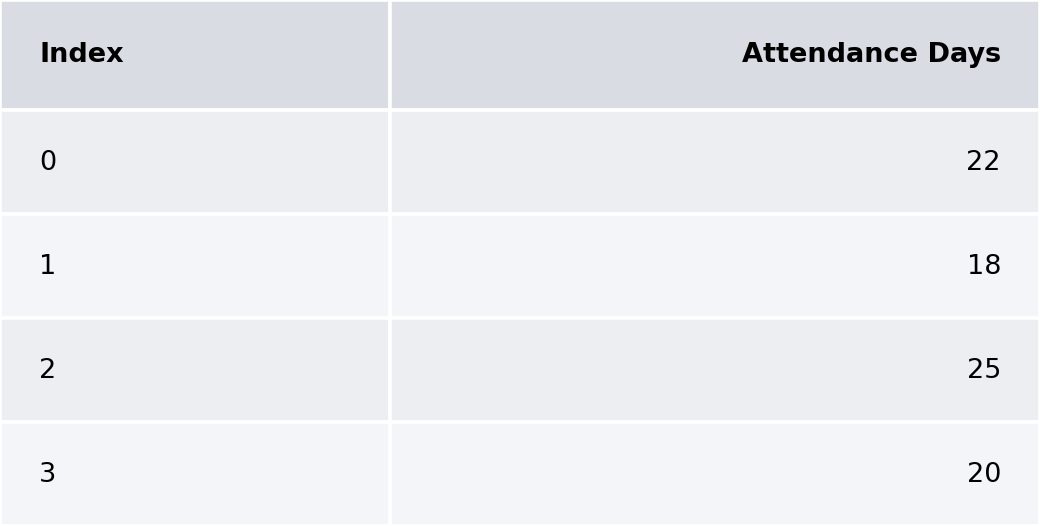

## Creating a Series

We create a Series using `pd.Series()` and pass a ***list*** of values.

In [2]:
attendance = pd.Series([22, 18, 25, 20])
print(attendance)

0    22
1    18
2    25
3    20
dtype: int64


Here:

* The left column (`0, 1, 2, 3`) is the ***index***, generated automatically
* The right column holds the ***values***
* `dtype: int64` shows the data type of the values

## Exploring a Series

A Series has useful attributes:

* `.values`: the values
* `.index`: the index
* `.dtype`: the data type
* `.size`: number of values

In [3]:
print("Values:", attendance.values)
print("Index :", list(attendance.index))
print("Type  :", attendance.dtype)
print("Size  :", attendance.size)

Values: [22 18 25 20]
Index : [0, 1, 2, 3]
Type  : int64
Size  : 4


## Accessing Values from a Series

Just like lists, we can access a value using its index.

In [4]:
print(attendance[0])    # first value
print(attendance[2])    # third value

22
25


## Calculations on a Series

A Series has built-in functions for quick calculations. Compare this with the loop we wrote in Module 1 to find a total.

In [5]:
print("Total attendance  :", attendance.sum())
print("Average attendance:", attendance.mean())
print("Highest           :", attendance.max())
print("Lowest            :", attendance.min())

Total attendance  : 85
Average attendance: 21.25
Highest           : 25
Lowest            : 18


## Series with a Custom Index (Extra)

**Note**: This section is not in the lecture slides.

The index does not have to be `0, 1, 2, 3`. We can give meaningful labels, such as employee names.

In [6]:
attendance_named = pd.Series([22, 18, 25, 20], index=["Ravi", "Meena", "Arjun", "Sara"])
print(attendance_named)

Ravi     22
Meena    18
Arjun    25
Sara     20
dtype: int64


In [7]:
print(attendance_named["Meena"])

18


## What is a DataFrame?

* A ***DataFrame*** is a two-dimensional Pandas object
* It has rows and columns
* Similar to an Excel sheet
* It can contain multiple Series
* Most business datasets are handled as DataFrames

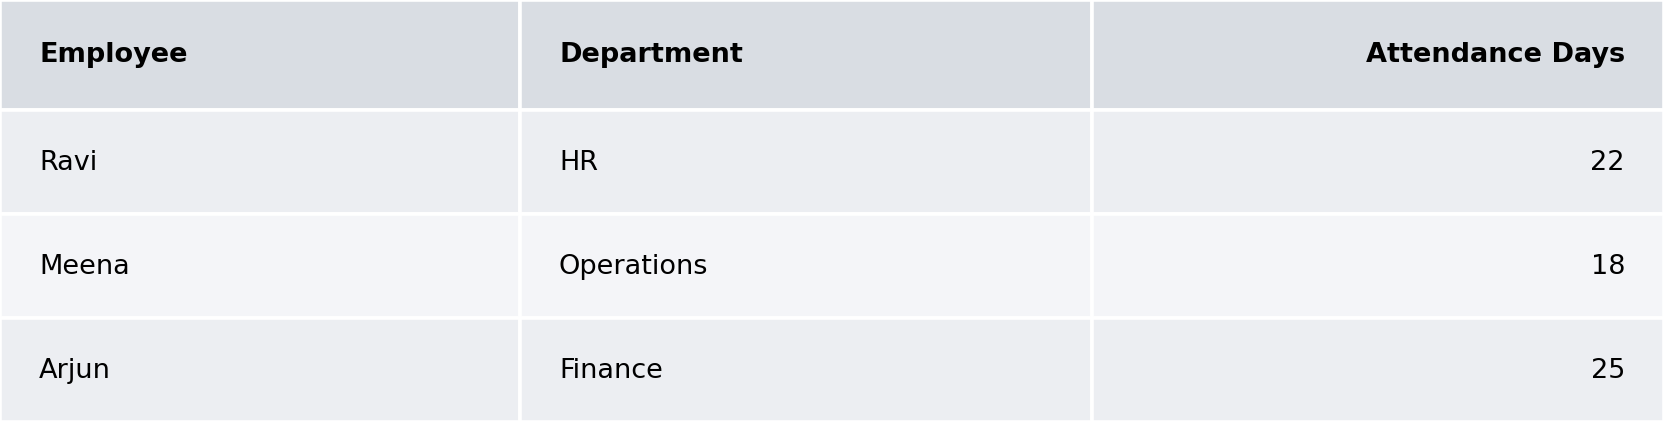

## Creating a DataFrame

We create a DataFrame from a ***dictionary***. Each key is a column name, and its list of values is the column.

In [8]:
data = {
    "Employee": ["Ravi", "Meena", "Arjun"],
    "Department": ["HR", "Operations", "Finance"],
    "Attendance Days": [22, 18, 25]
}

hr_data = pd.DataFrame(data)
hr_data

,Employee,Department,Attendance Days
0,Ravi,HR,22
1,Meena,Operations,18
2,Arjun,Finance,25


We can check the structure of the DataFrame:

In [9]:
print("Shape  :", hr_data.shape)
print("Columns:", list(hr_data.columns))
print("Index  :", list(hr_data.index))

Shape  : (3, 3)
Columns: ['Employee', 'Department', 'Attendance Days']
Index  : [0, 1, 2]


## Selecting One Column from a DataFrame

We select a column using its name in square brackets.

In [10]:
hr_data["Attendance Days"]

,Attendance Days
0,22
1,18
2,25


## A Column Behaves Like a Series

When we select one column from a DataFrame, we get a ***Series***. We can check this using `type()`.

In [11]:
print(type(hr_data))
print(type(hr_data["Attendance Days"]))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


Because the column is a Series, we can use all the Series functions on it:

In [12]:
attendance_days = hr_data["Attendance Days"]

print("Total attendance  :", attendance_days.sum())
print("Average attendance:", attendance_days.mean())
print("Highest           :", attendance_days.max())
print("Lowest            :", attendance_days.min())

Total attendance  : 65
Average attendance: 21.666666666666668
Highest           : 25
Lowest            : 18


To select more than one column, we use a ***list of column names***. The result is a DataFrame, not a Series.

In [13]:
subset = hr_data[["Employee", "Attendance Days"]]
print(type(subset))
subset

<class 'pandas.core.frame.DataFrame'>


,Employee,Attendance Days
0,Ravi,22
1,Meena,18
2,Arjun,25


## Series vs DataFrame

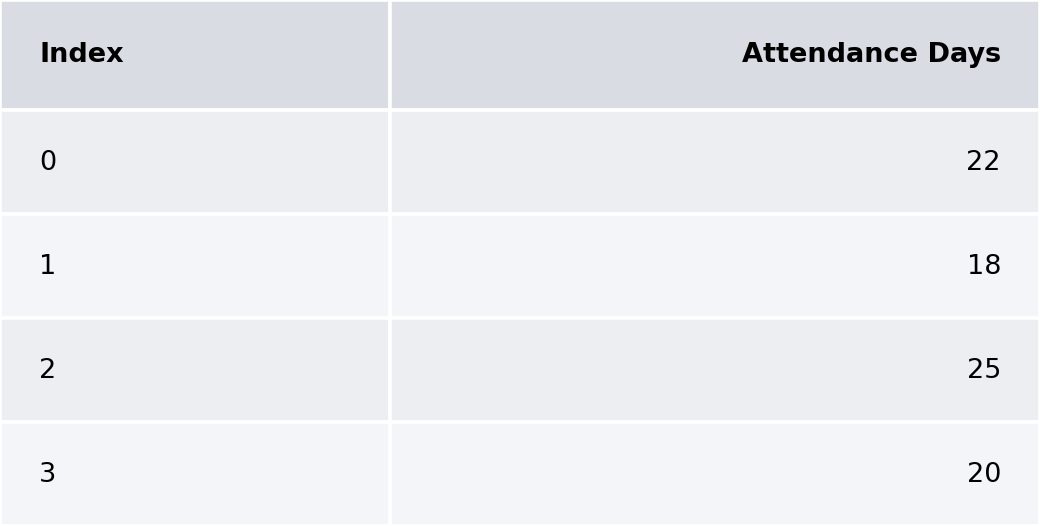

In [14]:
print("Series shape   :", hr_data["Attendance Days"].shape)   # one-dimensional
print("DataFrame shape:", hr_data.shape)                      # two-dimensional

Series shape   : (3,)
DataFrame shape: (3, 3)


## Interpreting HR Attendance Data

Let us look at the HR data from a business perspective:

* Which employee has the highest attendance?
* What is the average attendance across employees?
* Which employees have attendance below the average?

In [15]:
average = hr_data["Attendance Days"].mean()
print("Average attendance:", round(average, 1))

# Highest attendance
highest = hr_data["Attendance Days"].max()
print("Highest attendance:", highest)

Average attendance: 21.7
Highest attendance: 25


**Interpretation**: The average attendance is `21.7` days. Meena (Operations) has `18` days, which is below the average. HR can follow up to understand the reason, for example workload or leave. Arjun (Finance) has the highest attendance with `25` days.

**Note**: Filtering is covered in detail in the coming tutorials.

## Practice Questions

1. Create a Series called `sales` with the values `50000, 65000, 48000, 72000` and find its total and average.
2. Create a DataFrame called `products` with columns `Product`, `Category` and `Price` for 3 products.
3. Select the `Price` column and find its highest value. What type of object do you get?

In [16]:
# Answers
sales = pd.Series([50000, 65000, 48000, 72000])
print("Total  :", sales.sum())
print("Average:", sales.mean())

products = pd.DataFrame({
    "Product": ["Laptop", "Mouse", "Keyboard"],
    "Category": ["Computers", "Accessories", "Accessories"],
    "Price": [50000, 500, 1500]
})

price = products["Price"]
print("Highest price:", price.max())
print("Type:", type(price))

Total  : 235000
Average: 58750.0
Highest price: 50000
Type: <class 'pandas.core.series.Series'>


## Summary

In this tutorial, we learned:

* Pandas mainly uses two objects: ***Series*** and ***DataFrame***
* A Series is a one-dimensional object, like a single column of data
* A DataFrame is a two-dimensional object, like an entire Excel table
* We can create a Series from a list and a DataFrame from a dictionary
* Selecting one column from a DataFrame gives a Series
* Series functions such as `sum()`, `mean()`, `max()` and `min()` help interpret business data like HR attendance